# Práctica: Feature Engineering, Scaling y Vectorización

## Objetivos
En esta práctica aprenderás a:
- Implementar **regresión polinomial** (feature engineering) evaluando múltiples grados y seleccionando el óptimo
- Implementar los **3 métodos de feature scaling** vistos en clase y comparar cuál produce menor MSE
- Escribir todo el código de forma **vectorizada** usando operaciones de matrices y producto punto

---

## Herramientas
- NumPy: operaciones vectorizadas
- Matplotlib: visualización
- sklearn (solo al final para verificar)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import copy

np.set_printoptions(precision=4)
plt.style.use('seaborn-v0_8-darkgrid')

---
# 1. Dataset y Visualización

Usaremos datos de precios de casas. La relación entre tamaño y precio **no es lineal** — una recta no captura bien los datos.

In [2]:
# Dataset: tamaño (1000 sqft) → precio ($1000s)
x_train = np.array([0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 2.8, 3.0, 3.5])
y_train = np.array([90, 120, 140, 155, 180, 210, 230, 260, 300, 350, 380, 460])

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Número de ejemplos: m = {x_train.shape[0]}")

x_train shape: (12,)
y_train shape: (12,)
Número de ejemplos: m = 12


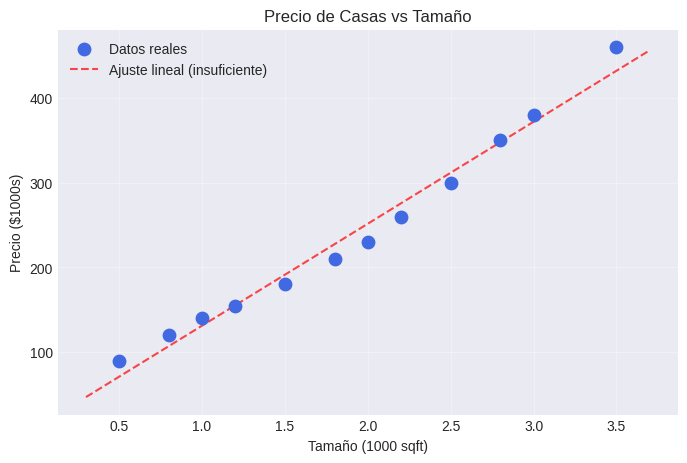


→ Observación: la relación NO es lineal. Necesitamos features polinomiales.


In [3]:
# Visualizar los datos
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, color='royalblue', s=80, zorder=5, label='Datos reales')

# Ajuste lineal simple para mostrar que no es suficiente
w_simple = np.polyfit(x_train, y_train, 1)
x_line = np.linspace(0.3, 3.7, 100)
plt.plot(x_line, np.polyval(w_simple, x_line), 'r--', alpha=0.7, label='Ajuste lineal (insuficiente)')

plt.xlabel('Tamaño (1000 sqft)')
plt.ylabel('Precio ($1000s)')
plt.title('Precio de Casas vs Tamaño')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n→ Observación: la relación NO es lineal. Necesitamos features polinomiales.")

---
# 2. Repaso: Producto Punto y Multiplicación de Matrices

Antes de implementar las funciones vectorizadas, repasemos cómo funciona la multiplicación de matrices y por qué es clave para hacer predicciones eficientes.

## 2.1 El Producto Punto (Dot Product)

El producto punto entre dos vectores $\mathbf{w}$ y $\mathbf{x}$ se define como:

$$\mathbf{w} \cdot \mathbf{x} = \sum_{j=0}^{n-1} w_j \cdot x_j$$

**Ejemplo numérico:**

$$\mathbf{w} = [2, 3, 1], \quad \mathbf{x} = [4, 1, 5]$$
$$\mathbf{w} \cdot \mathbf{x} = 2 \times 4 + 3 \times 1 + 1 \times 5 = 8 + 3 + 5 = 16$$

In [4]:
# Ejemplo: producto punto con loop vs np.dot
w = np.array([2, 3, 1])
x = np.array([4, 1, 5])

# Versión con loop (LENTA)
resultado_loop = 0
for j in range(len(w)):
    resultado_loop += w[j] * x[j]

# Versión vectorizada (RÁPIDA)
resultado_dot = np.dot(w, x)

print(f"Con loop:   w · x = {resultado_loop}")
print(f"Con np.dot: w · x = {resultado_dot}")
print(f"\n✓ Ambos dan el mismo resultado, pero np.dot es mucho más rápido para vectores grandes.")

Con loop:   w · x = 16
Con np.dot: w · x = 16

✓ Ambos dan el mismo resultado, pero np.dot es mucho más rápido para vectores grandes.


## 2.2 Multiplicación Matriz × Vector = Colección de Dot Products

Cuando multiplicamos una matriz $\mathbf{X}$ de shape $(m, n)$ por un vector $\mathbf{w}$ de shape $(n,)$, el resultado es un vector de $m$ elementos donde **cada elemento es el producto punto de una fila de X con w**:

$$\mathbf{X} \cdot \mathbf{w} = \begin{pmatrix} \text{fila}_0 \cdot \mathbf{w} \\ \text{fila}_1 \cdot \mathbf{w} \\ \vdots \\ \text{fila}_{m-1} \cdot \mathbf{w} \end{pmatrix}$$

<img src="https://upload.wikimedia.org/wikipedia/commons/8/86/Matrix_multiplication_.gif" width="400">

**Esto es exactamente lo que necesitamos para hacer predicciones:**
- Cada fila de $\mathbf{X}$ es un ejemplo (una casa con sus features)
- $\mathbf{w}$ son los pesos del modelo
- El resultado es un vector con la predicción para cada casa

$$\text{predicciones} = \mathbf{X} \cdot \mathbf{w} + b$$

In [5]:
# Demostración: predecir para 3 casas con 2 features cada una
X_demo = np.array([
    [1.5, 3],   # casa 0: 1500sqft, 3 cuartos
    [2.0, 4],   # casa 1: 2000sqft, 4 cuartos
    [1.0, 2],   # casa 2: 1000sqft, 2 cuartos
])
w_demo = np.array([100, 20])  # $100k por 1000sqft, $20k por cuarto
b_demo = 50  # base $50k

print("=== Predicción con LOOP (lento) ===")
for i in range(X_demo.shape[0]):
    pred_i = np.dot(X_demo[i], w_demo) + b_demo
    print(f"  Casa {i}: fila {X_demo[i]} · w {w_demo} + {b_demo} = {pred_i}")

print("\n=== Predicción VECTORIZADA (rápido) ===")
predicciones = X_demo @ w_demo + b_demo  # equivale a np.dot(X_demo, w_demo) + b_demo
print(f"  X @ w + b = {predicciones}")
print(f"\n✓ Una sola operación reemplaza el loop completo!")
print(f"  Shapes: X({X_demo.shape}) @ w({w_demo.shape}) + b → predicciones({predicciones.shape})")

=== Predicción con LOOP (lento) ===
  Casa 0: fila [1.5 3. ] · w [100  20] + 50 = 260.0
  Casa 1: fila [2. 4.] · w [100  20] + 50 = 330.0
  Casa 2: fila [1. 2.] · w [100  20] + 50 = 190.0

=== Predicción VECTORIZADA (rápido) ===
  X @ w + b = [260. 330. 190.]

✓ Una sola operación reemplaza el loop completo!
  Shapes: X((3, 2)) @ w((2,)) + b → predicciones((3,))


## 2.3 Ejercicio: Implementar predicción vectorizada

Implementa una función que prediga el precio de **todas** las casas simultáneamente usando código vectorizado.

**Reglas:**
- NO puedes usar loops
- Usa `@` o `np.dot` para la multiplicación matriz-vector

In [6]:
def predict_all(X, w, b):
    """
    Predice para todos los ejemplos simultáneamente.

    Args:
        X (ndarray (m,n)): matriz de features, m ejemplos, n features
        w (ndarray (n,)):  vector de pesos
        b (scalar):        bias

    Returns:
        predictions (ndarray (m,)): vector de predicciones
    """
    predictions = np.dot(X, w) + b
    return predictions
    pass

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista</span></summary>

```python
# La multiplicación matriz × vector hace dot product fila por fila:
predictions = X @ w + b
# equivalente a: np.dot(X, w) + b
```

</details>

In [7]:
# Verificar tu implementación
preds = predict_all(X_demo, w_demo, b_demo)
print(f"Predicciones: {preds}")
print(f"Esperado:     [260. 330. 190.]")
assert preds is not None, "La función retorna None — implementa el código"
assert np.allclose(preds, [260, 330, 190]), f"Error: esperado [260, 330, 190], obtuviste {preds}"
print("\n✓ ¡Correcto!")

Predicciones: [260. 330. 190.]
Esperado:     [260. 330. 190.]

✓ ¡Correcto!


---
# 3. Feature Engineering: Regresión Polinomial

## 3.1 La Idea

Si los datos no son lineales, podemos crear **nuevas features** a partir de las existentes:

$$f(x) = w_1 x + w_2 x^2 + w_3 x^3 + \ldots + w_d x^d + b$$

Esto transforma un problema no-lineal en uno **lineal en las features**:

| Feature original | Features polinomiales (grado 3) |
|:---:|:---:|
| $x$ | $x_1 = x$, $x_2 = x^2$, $x_3 = x^3$ |

Ahora el modelo es lineal en $[x_1, x_2, x_3]$:
$$f(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b$$

**⚠️ Importante:** Como $x^2, x^3$ crecen rápidamente, es **crucial** aplicar feature scaling después de crear las features polinomiales.

## 3.2 Crear Features Polinomiales

In [8]:
def create_polynomial_features(x, degree):
    """
    Crea una matriz de features polinomiales.

    Args:
        x (ndarray (m,)): vector de una sola feature
        degree (int):     grado máximo del polinomio

    Returns:
        X (ndarray (m, degree)): matriz con columnas [x, x², x³, ..., x^degree]

    Ejemplo:
        x = [2, 3], degree = 3
        X = [[2, 4, 8],
             [3, 9, 27]]
    """
    # Nota: esto es vectorizado — no hay loop sobre los m ejemplos
    # x**k eleva TODOS los elementos simultáneamente (operación element-wise)
    return np.column_stack([x**k for k in range(1, degree + 1)])


# Demostración
x_ejemplo = np.array([1.0, 2.0, 3.0])
X_poly = create_polynomial_features(x_ejemplo, degree=3)
print(f"x original: {x_ejemplo}")
print(f"\nX polinomial (grado 3):")
print(f"  [x,  x²,  x³]")
print(X_poly)
print(f"\nShape: {X_poly.shape} → {X_poly.shape[0]} ejemplos, {X_poly.shape[1]} features")

x original: [1. 2. 3.]

X polinomial (grado 3):
  [x,  x²,  x³]
[[ 1.  1.  1.]
 [ 2.  4.  8.]
 [ 3.  9. 27.]]

Shape: (3, 3) → 3 ejemplos, 3 features


## 3.3 Funciones de Entrenamiento

### Función de Costo:
$$J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2$$

### Gradientes:
$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})$$

A continuación se presenta la implementación **con loops** (referencia). Tu tarea será implementar la versión **vectorizada**.

In [9]:
# ============================================================
# REFERENCIA: Implementación CON LOOPS (lenta pero clara)
# ============================================================

def compute_cost_loop(X, y, w, b):
    """
    Calcula el costo MSE usando loops.
    Funciona pero es LENTA para datasets grandes.
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b    # predicción para ejemplo i
        cost += (f_wb_i - y[i])**2        # error cuadrado acumulado
    cost = cost / (2 * m)
    return cost


def compute_gradient_loop(X, y, w, b):
    """
    Calcula gradientes usando loops.
    Funciona pero es LENTA para datasets grandes.
    """
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i, j]
        dj_db += err

    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_dw, dj_db


# Verificar que funcionan
X_test = create_polynomial_features(x_train, 2)
w_test = np.zeros(2)
b_test = 0.0

cost_loop = compute_cost_loop(X_test, y_train, w_test, b_test)
dj_dw_loop, dj_db_loop = compute_gradient_loop(X_test, y_train, w_test, b_test)
print(f"Cost (loop):     {cost_loop:.4f}")
print(f"Gradient (loop): dj_dw = {dj_dw_loop}, dj_db = {dj_db_loop:.4f}")
print("\n✓ Estas funciones son CORRECTAS pero LENTAS. Ahora implementa la versión vectorizada.")

Cost (loop):     34651.0417
Gradient (loop): dj_dw = [ -552.25  -1450.025], dj_db = -239.5833

✓ Estas funciones son CORRECTAS pero LENTAS. Ahora implementa la versión vectorizada.


## 3.4 Ejercicio: Implementar costo vectorizado

Implementa `compute_cost` **sin loops**. El resultado debe ser idéntico al de `compute_cost_loop`.

**Recordatorio de cómo vectorizar:**
- `X @ w + b` calcula TODAS las predicciones de golpe (un dot product por fila de X)
- `predictions - y` calcula todos los errores de golpe (operación element-wise)
- `np.mean(errors**2)` calcula la media de los errores al cuadrado

Observa la relación:

| Loop | Vectorizado |
|:-----|:------------|
| `for i in range(m): f_wb_i = np.dot(X[i], w) + b` | `predictions = X @ w + b` |
| `for i: cost += (f_wb_i - y[i])**2` | `cost = np.mean((predictions - y)**2) / 2` |

In [10]:
def compute_cost(X, y, w, b):
    """
    Calcula el costo MSE de forma VECTORIZADA (sin loops).

    Args:
        X (ndarray (m,n)): features
        y (ndarray (m,)):  targets
        w (ndarray (n,)):  pesos
        b (scalar):        bias

    Returns:
        cost (scalar): valor del costo J(w,b)
    """
    predictions = np.dot(X, w) + b
    errors = predictions - y
    cost = np.mean(errors**2) / 2
    return cost
    pass

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista — compute_cost vectorizado</span></summary>

```python
predictions = X @ w + b            # (m,n) @ (n,) → (m,)
errors = predictions - y            # (m,)
cost = np.mean(errors**2) / 2       # scalar
return cost
```

</details>

In [11]:
# Verificar: tu resultado debe ser igual al de la versión con loop
cost_vec = compute_cost(X_test, y_train, w_test, b_test)
print(f"Cost (loop):        {cost_loop:.6f}")
print(f"Cost (vectorizado): {cost_vec}")
assert cost_vec is not None, "compute_cost retorna None — implementa el código"
assert np.isclose(cost_vec, cost_loop), f"Error: esperado {cost_loop:.6f}, obtuviste {cost_vec}"
print("\n✓ ¡Correcto! Mismo resultado, sin loops.")

Cost (loop):        34651.041667
Cost (vectorizado): 34651.041666666664

✓ ¡Correcto! Mismo resultado, sin loops.


## 3.5 Ejercicio: Implementar gradiente vectorizado

Implementa `compute_gradient` **sin loops**. El resultado debe ser idéntico al de `compute_gradient_loop`.

**Truco clave para `dj_dw`:**

El loop original hace:
```
for i in range(m):
    err = predicción_i - y_i
    for j in range(n):
        dj_dw[j] += err * X[i, j]
```

Esto es equivalente a multiplicar la **transpuesta** de X por el vector de errores:

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T \cdot \mathbf{errors}$$

¿Por qué? Porque $\mathbf{X}^T$ tiene shape $(n, m)$. Al multiplicar por `errors` de shape $(m,)$:
- Cada **fila** de $\mathbf{X}^T$ (que es una **columna** de $\mathbf{X}$, es decir, todos los valores de una feature) hace dot product con el vector de errores.
- Resultado: un vector de shape $(n,)$ con el gradiente de cada peso.

<img src="https://anakarinarm.github.io/python-novice-inflammation-2016-09-20-ubc/fig/python-operations-across-axes.png" width="500">

In [14]:
def compute_gradient(X, y, w, b):
    """
    Calcula gradientes de forma VECTORIZADA (sin loops).

    Args:
        X (ndarray (m,n)): features
        y (ndarray (m,)):  targets
        w (ndarray (n,)):  pesos
        b (scalar):        bias

    Returns:
        dj_dw (ndarray (n,)): gradiente respecto a w
        dj_db (scalar):       gradiente respecto a b
    """
    m, n = X.shape
    predictions = np.dot(X, w) + b
    errors = predictions - y
    dj_dw = (X.T @ errors) / m
    dj_db = np.mean(errors)
    return dj_dw, dj_db
    pass

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista — compute_gradient vectorizado</span></summary>

```python
m = X.shape[0]
predictions = X @ w + b          # (m,)
errors = predictions - y          # (m,)

dj_dw = (X.T @ errors) / m       # (n,m) @ (m,) → (n,)
dj_db = np.mean(errors)           # scalar
return dj_dw, dj_db
```
`X.T @ errors` hace un dot product por cada feature (fila de X.T) con el vector de errores.

</details>

In [15]:
# Verificar: tu resultado debe ser igual al de la versión con loop
dj_dw_vec, dj_db_vec = compute_gradient(X_test, y_train, w_test, b_test)
print(f"Gradient (loop):        dj_dw = {dj_dw_loop}, dj_db = {dj_db_loop:.4f}")
print(f"Gradient (vectorizado): dj_dw = {dj_dw_vec}, dj_db = {dj_db_vec}")
assert dj_dw_vec is not None, "compute_gradient retorna None — implementa el código"
assert np.allclose(dj_dw_vec, dj_dw_loop), f"Error en dj_dw: esperado {dj_dw_loop}, obtuviste {dj_dw_vec}"
assert np.isclose(dj_db_vec, dj_db_loop), f"Error en dj_db: esperado {dj_db_loop}, obtuviste {dj_db_vec}"
print("\n✓ ¡Correcto! Mismo resultado, sin loops.")

Gradient (loop):        dj_dw = [ -552.25  -1450.025], dj_db = -239.5833
Gradient (vectorizado): dj_dw = [ -552.25  -1450.025], dj_db = -239.58333333333334

✓ ¡Correcto! Mismo resultado, sin loops.


In [16]:
# Comparar velocidad: loop vs vectorizado
# Usamos un dataset más grande para notar la diferencia
X_big = np.random.randn(5000, 10)
y_big = np.random.randn(5000)
w_big = np.random.randn(10)

tic = time.time()
for _ in range(100):
    compute_cost_loop(X_big, y_big, w_big, 0.0)
time_loop = time.time() - tic

tic = time.time()
for _ in range(100):
    compute_cost(X_big, y_big, w_big, 0.0)
time_vec = time.time() - tic

print(f"Cost con loop:        {time_loop*1000:.1f} ms (100 repeticiones)")
print(f"Cost vectorizado:     {time_vec*1000:.1f} ms (100 repeticiones)")
print(f"\n→ Speedup: {time_loop/time_vec:.0f}x más rápido con vectorización!")

Cost con loop:        956.4 ms (100 repeticiones)
Cost vectorizado:     5.4 ms (100 repeticiones)

→ Speedup: 176x más rápido con vectorización!


## 3.6 Gradient Descent (dado)

Esta función usa tus implementaciones vectorizadas de `compute_cost` y `compute_gradient` para entrenar el modelo.

In [17]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    """
    Ejecuta gradient descent usando las funciones vectorizadas del estudiante.
    """
    w = copy.deepcopy(w_init)
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J_history.append(compute_cost(X, y, w, b))

        if i % (num_iters // 5) == 0:
            print(f"  Iter {i:5d}: Cost = {J_history[-1]:.4f}")

    return w, b, J_history

print("✓ gradient_descent definido (usa TUS funciones vectorizadas).")

✓ gradient_descent definido (usa TUS funciones vectorizadas).


## 3.7 Ejercicio: Evaluar grados 1 a 6

Entrena un modelo para cada grado polinomial (1 a 6). Para cada grado debes:
1. Crear las features polinomiales
2. Aplicar z-score normalization
3. Entrenar con gradient descent
4. Guardar el MSE final

**Recuerda:** La función z-score es:
$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

In [18]:
degrees = [1, 2, 3, 4, 5, 6]
results = {}  # almacenará {grado: {'w': w, 'b': b, 'mse': mse, 'mu': mu, 'sigma': sigma}}

alpha = 0.1
num_iters = 5000

for deg in degrees:
    print(f"\n{'='*50}")
    print(f"Grado {deg}:")
    print(f"{'='*50}")

    # Paso 1: Crear features polinomiales
    # YOUR CODE HERE — usa create_polynomial_features(x_train, deg)
    X_poly = create_polynomial_features(x_train, deg)  # ← reemplaza esto

    # Paso 2: Aplicar z-score normalization
    # YOUR CODE HERE — calcula mu, sigma, y normaliza X_poly
    mu =    X_poly.mean(axis=0)    # ← reemplaza esto
    sigma = X_poly.std(axis=0)    # ← reemplaza esto
    X_norm = (X_poly - mu) / sigma   # ← reemplaza esto

    # Paso 3: Entrenar
    w_init = np.zeros(deg)
    b_init = 0.0
    w_final, b_final, J_hist = gradient_descent(X_norm, y_train, w_init, b_init, alpha, num_iters)

    # Paso 4: Calcular MSE final
    # YOUR CODE HERE — MSE = (1/m) * sum((predicción - y)²)
    predictions = np.dot(X_norm, w_final) + b_final
    mse = np.mean((predictions - y_train)**2)  # ← reemplaza esto

    results[deg] = {'w': w_final, 'b': b_final, 'mse': mse, 'mu': mu, 'sigma': sigma}
    print(f"  MSE final: {mse}")


Grado 1:
  Iter     0: Cost = 28088.9883
  Iter  1000: Cost = 113.9187
  Iter  2000: Cost = 113.9187
  Iter  3000: Cost = 113.9187
  Iter  4000: Cost = 113.9187
  MSE final: 227.83732208448123

Grado 2:
  Iter     0: Cost = 27081.8270
  Iter  1000: Cost = 7.7805
  Iter  2000: Cost = 7.7385
  Iter  3000: Cost = 7.7381
  Iter  4000: Cost = 7.7381
  MSE final: 15.476177938400523

Grado 3:
  Iter     0: Cost = 26237.9740
  Iter  1000: Cost = 7.2174
  Iter  2000: Cost = 7.2173
  Iter  3000: Cost = 7.2171
  Iter  4000: Cost = 7.2170
  MSE final: 14.433848659465655

Grado 4:
  Iter     0: Cost = 25565.3658
  Iter  1000: Cost = 7.2402
  Iter  2000: Cost = 7.1859
  Iter  3000: Cost = 7.1448
  Iter  4000: Cost = 7.1122
  MSE final: 14.17026961367919

Grado 5:
  Iter     0: Cost = 25050.2938
  Iter  1000: Cost = 6.7447
  Iter  2000: Cost = 6.6333
  Iter  3000: Cost = 6.5485
  Iter  4000: Cost = 6.4739
  MSE final: 12.807261402471696

Grado 6:
  Iter     0: Cost = 24673.3149
  Iter  1000: Cost = 

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista — Paso 1</span></summary>

```python
X_poly = create_polynomial_features(x_train, deg)
```

</details>

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista — Paso 2 (z-score)</span></summary>

```python
mu = X_poly.mean(axis=0)      # media de cada columna
sigma = X_poly.std(axis=0)    # std de cada columna
X_norm = (X_poly - mu) / sigma
```
Nota: `axis=0` opera sobre las filas → resultado tiene shape (n,), una media/std por feature.

</details>

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista — Paso 4 (MSE)</span></summary>

```python
predictions = X_norm @ w_final + b_final
mse = np.mean((predictions - y_train)**2)
```

</details>

## 3.8 Visualización Comparativa

Ejecuta la siguiente celda para ver las curvas de cada grado y comparar MSE.

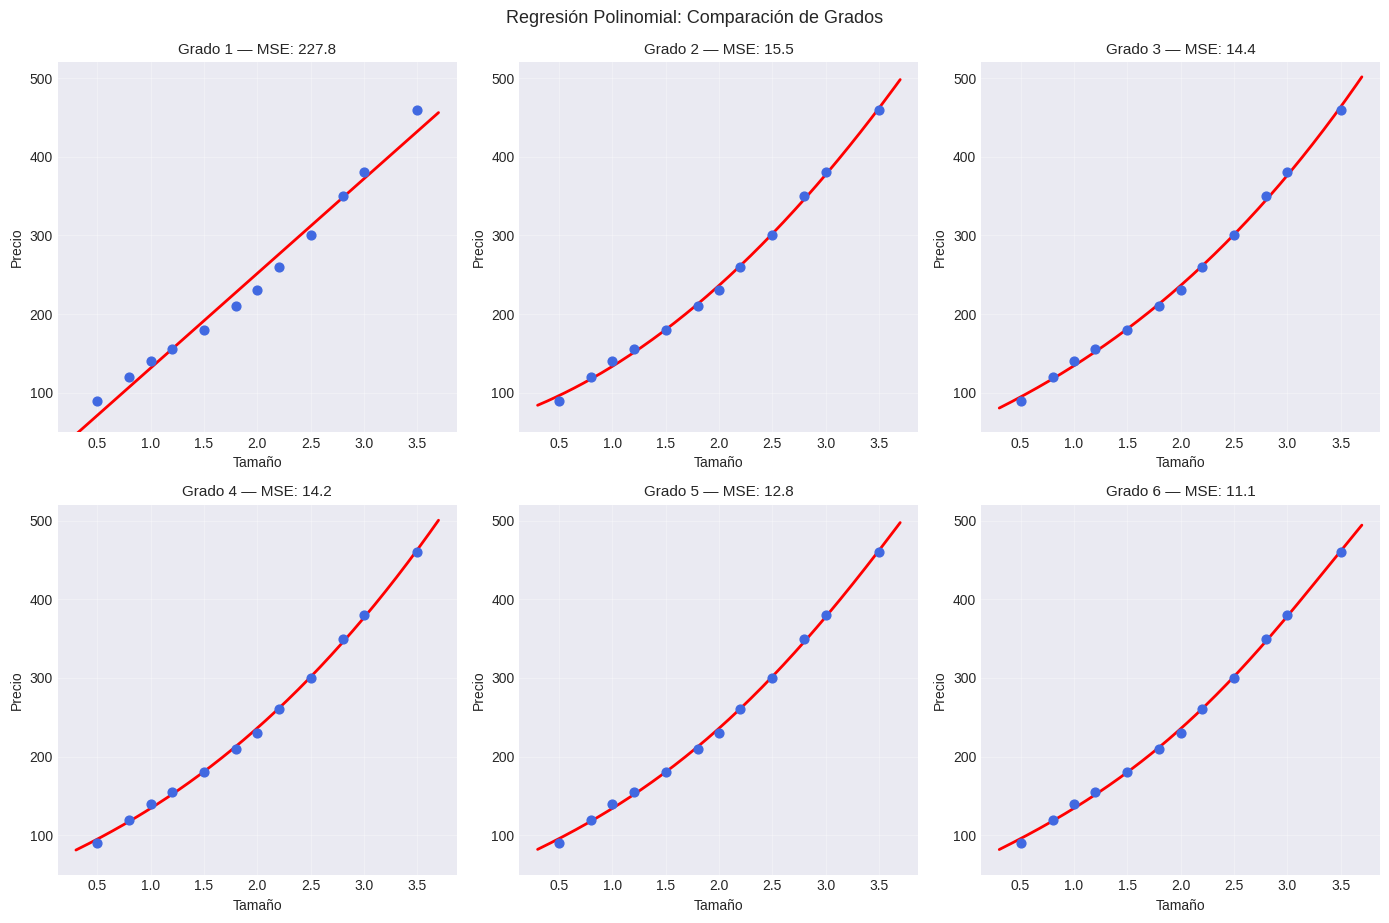


Grado   MSE            Ranking
  6     11.07          1 ← MEJOR
  5     12.81          2
  4     14.17          3
  3     14.43          4
  2     15.48          5
  1     227.84         6


In [19]:
# Visualización: curvas ajustadas para cada grado
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
x_plot = np.linspace(0.3, 3.7, 200)

for idx, deg in enumerate(degrees):
    ax = axes[idx // 3, idx % 3]
    ax.scatter(x_train, y_train, color='royalblue', s=40, zorder=5)

    if results[deg]['mse'] is not None:
        # Generar curva de predicción
        X_plot_poly = create_polynomial_features(x_plot, deg)
        X_plot_norm = (X_plot_poly - results[deg]['mu']) / results[deg]['sigma']
        y_plot = X_plot_norm @ results[deg]['w'] + results[deg]['b']
        ax.plot(x_plot, y_plot, 'r-', linewidth=2)
        ax.set_title(f"Grado {deg} — MSE: {results[deg]['mse']:.1f}", fontsize=11)
    else:
        ax.set_title(f"Grado {deg} — Sin completar", fontsize=11, color='gray')

    ax.set_xlabel('Tamaño')
    ax.set_ylabel('Precio')
    ax.set_ylim([50, 520])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Regresión Polinomial: Comparación de Grados', fontsize=13, y=1.02)
plt.show()

# Tabla de resultados
print("\n" + "="*40)
print(f"{'Grado':<8}{'MSE':<15}{'Ranking'}")
print("="*40)
valid_results = {k: v for k, v in results.items() if v['mse'] is not None}
if valid_results:
    sorted_degrees = sorted(valid_results.keys(), key=lambda d: valid_results[d]['mse'])
    for rank, deg in enumerate(sorted_degrees, 1):
        marker = " ← MEJOR" if rank == 1 else ""
        print(f"  {deg:<6}{valid_results[deg]['mse']:<15.2f}{rank}{marker}")

## 3.9 Pregunta de Reflexión

Basándote en los resultados:
1. ¿Cuál es el mejor grado polinomial para estos datos?
2. ¿Por qué grados muy altos (5, 6) no necesariamente dan mejor MSE de entrenamiento?
3. ¿Qué riesgo existe al usar un grado muy alto? (piensa en datos nuevos)

*Escribe tu respuesta abajo:*

**Tu respuesta aquí:**

1. ...
2. ...
3. ...

---
# 4. Feature Scaling: Comparativa de 3 Métodos

## 4.1 El Problema

Cuando las features tienen **escalas muy diferentes**, gradient descent converge lentamente porque los gradientes están dominados por las features grandes.

Ejemplo: `size` va de 852 a 2104, pero `bedrooms` solo de 2 a 5.

In [20]:
# Dataset multi-feature para la comparativa de scaling
# size(sqft), bedrooms, age(años) → price($1000s)
X_multi = np.array([
    [2104, 5, 45],
    [1416, 3, 40],
    [852,  2, 35],
    [1534, 3, 30],
    [2000, 4, 50],
    [1200, 2, 25],
    [1800, 4, 42],
    [950,  2, 20],
    [1600, 3, 38],
    [2200, 5, 55]
])
y_multi = np.array([460, 232, 178, 252, 380, 195, 320, 160, 275, 490])

print("Rangos de cada feature (sin escalar):")
print(f"  size:     [{X_multi[:,0].min():.0f}, {X_multi[:,0].max():.0f}]  rango = {X_multi[:,0].max() - X_multi[:,0].min():.0f}")
print(f"  bedrooms: [{X_multi[:,1].min():.0f}, {X_multi[:,1].max():.0f}]    rango = {X_multi[:,1].max() - X_multi[:,1].min():.0f}")
print(f"  age:      [{X_multi[:,2].min():.0f}, {X_multi[:,2].max():.0f}]   rango = {X_multi[:,2].max() - X_multi[:,2].min():.0f}")
print("\n→ El rango de 'size' es ~400x mayor que 'bedrooms'. Esto causa problemas en GD.")

Rangos de cada feature (sin escalar):
  size:     [852, 2200]  rango = 1348
  bedrooms: [2, 5]    rango = 3
  age:      [20, 55]   rango = 35

→ El rango de 'size' es ~400x mayor que 'bedrooms'. Esto causa problemas en GD.


## 4.2 Método 1: Min-Max Scaling

$$x_{\text{scaled}} = \frac{x}{\max(x)}$$

Resultado: cada feature queda en rango $[0, 1]$ aproximadamente.

**Ejercicio:** Implementa la función. Debe ser vectorizada (sin loops).

In [21]:
def min_max_scale(X):
    """
    Aplica Min-Max Scaling: divide cada feature por su valor máximo.

    Args:
        X (ndarray (m,n)): matriz de features

    Returns:
        X_scaled (ndarray (m,n)): features escaladas
        params (dict): parámetros para re-escalar datos nuevos
    """
    # YOUR CODE HERE
    X_scaled = X.max(axis=0)  # ← reemplaza esto

    params = {'max': X.max(axis=0)}
    return X_scaled, params

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista</span></summary>

```python
X_scaled = X / X.max(axis=0)
```
`X.max(axis=0)` retorna el máximo de cada columna → shape (n,).  
NumPy broadcasting divide cada columna de X por su máximo.

</details>

## 4.3 Método 2: Mean Normalization

$$x_{\text{scaled}} = \frac{x - \mu}{\max(x) - \min(x)}$$

Resultado: cada feature queda centrada en 0, rango $\approx [-0.5, 0.5]$.

**Ejercicio:** Implementa la función de forma vectorizada.

In [22]:
def mean_normalize(X):
    """
    Aplica Mean Normalization.

    Args:
        X (ndarray (m,n)): matriz de features

    Returns:
        X_scaled (ndarray (m,n)): features escaladas
        params (dict): parámetros {mu, rango} para re-escalar datos nuevos
    """
    # YOUR CODE HERE
    mu = X.mean(axis=0)       # ← media de cada feature
    rango = X.max(axis=0) - X.min(axis=0)    # ← max - min de cada feature
    X_scaled = (X - mu) / rango # ← aplicar la fórmula

    params = {'mu': mu, 'rango': rango}
    return X_scaled, params

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista</span></summary>

```python
mu = X.mean(axis=0)
rango = X.max(axis=0) - X.min(axis=0)
X_scaled = (X - mu) / rango
```

</details>

## 4.4 Método 3: Z-Score Normalization (Estandarización)

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

Resultado: cada feature tiene media = 0 y desviación estándar = 1.

**Ejercicio:** Implementa la función de forma vectorizada.

In [23]:
def z_score_normalize(X):
    """
    Aplica Z-Score Normalization (estandarización).

    Args:
        X (ndarray (m,n)): matriz de features

    Returns:
        X_scaled (ndarray (m,n)): features escaladas
        params (dict): parámetros {mu, sigma} para re-escalar datos nuevos
    """
    # YOUR CODE HERE
    mu = X.mean(axis=0)       # ← media de cada feature
    sigma = X.std(axis=0)    # ← desviación estándar de cada feature
    X_scaled = (X - mu) / sigma # ← aplicar la fórmula

    params = {'mu': mu, 'sigma': sigma}
    return X_scaled, params

<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista</span></summary>

```python
mu = X.mean(axis=0)
sigma = X.std(axis=0)
X_scaled = (X - mu) / sigma
```

</details>

## 4.5 Comparativa: Entrenar con cada método

Ahora entrenaremos el modelo **4 veces** con los mismos datos pero diferente scaling, y compararemos:
1. Sin scaling
2. Min-Max
3. Mean Normalization
4. Z-Score

In [25]:
# Configuración del experimento
alpha_scaling = 1e-7  # learning rate pequeño (necesario sin scaling)
alpha_scaled = 0.1     # learning rate normal (con scaling)
iters = 3000
n_features = X_multi.shape[1]

scaling_results = {}

# --- Experimento 1: Sin scaling ---
print("="*50)
print("Sin Scaling (alpha muy pequeño):")
print("="*50)
w0, b0, J0 = gradient_descent(X_multi, y_multi, np.zeros(n_features), 0.0, alpha_scaling, iters)
mse0 = np.mean((X_multi @ w0 + b0 - y_multi)**2)
scaling_results['Sin scaling'] = {'J_hist': J0, 'mse': mse0, 'color': 'red'}

# --- Experimento 2: Min-Max ---
print("\n" + "="*50)
print("Min-Max Scaling:")
print("="*50)
X_mm, params_mm = min_max_scale(X_multi)
if X_mm is not None:
    w1, b1, J1 = gradient_descent(X_mm, y_multi, np.zeros(n_features), 0.0, alpha_scaled, iters)
    mse1 = np.mean((X_mm @ w1 + b1 - y_multi)**2)
    scaling_results['Min-Max'] = {'J_hist': J1, 'mse': mse1, 'color': 'blue'}
else:
    print("  ⚠️ min_max_scale() no implementada")

# --- Experimento 3: Mean Normalization ---
print("\n" + "="*50)
print("Mean Normalization:")
print("="*50)
X_mn, params_mn = mean_normalize(X_multi)
if X_mn is not None:
    w2, b2, J2 = gradient_descent(X_mn, y_multi, np.zeros(n_features), 0.0, alpha_scaled, iters)
    mse2 = np.mean((X_mn @ w2 + b2 - y_multi)**2)
    scaling_results['Mean Norm'] = {'J_hist': J2, 'mse': mse2, 'color': 'green'}
else:
    print("  ⚠️ mean_normalize() no implementada")

# --- Experimento 4: Z-Score ---
print("\n" + "="*50)
print("Z-Score Normalization:")
print("="*50)
X_zs, params_zs = z_score_normalize(X_multi)
if X_zs is not None:
    w3, b3, J3 = gradient_descent(X_zs, y_multi, np.zeros(n_features), 0.0, alpha_scaled, iters)
    mse3 = np.mean((X_zs @ w3 + b3 - y_multi)**2)
    scaling_results['Z-Score'] = {'J_hist': J3, 'mse': mse3, 'color': 'purple'}
else:
    print("  ⚠️ z_score_normalize() no implementada")

Sin Scaling (alpha muy pequeño):
  Iter     0: Cost = 26986.9952
  Iter   600: Cost = 738.4275
  Iter  1200: Cost = 738.3550
  Iter  1800: Cost = 738.2828
  Iter  2400: Cost = 738.2108

Min-Max Scaling:


ValueError: not enough values to unpack (expected 2, got 1)

## 4.6 Visualización de Convergencia

/tmp/ipykernel_21771/1602747776.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


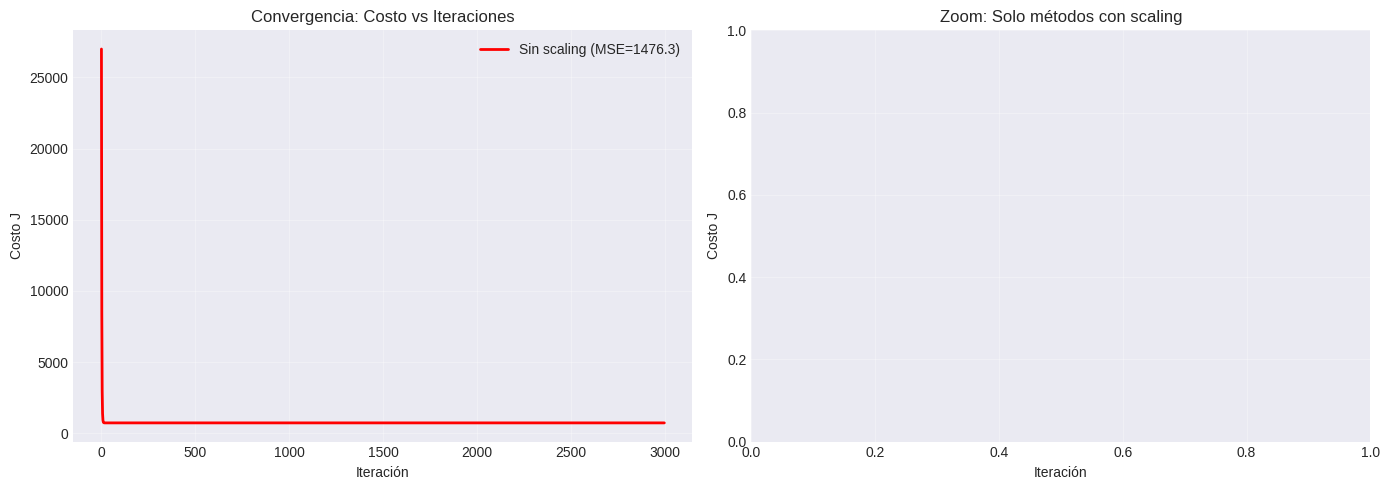


Método            MSE Final      Convergió?
  Sin scaling     1476.28        Parcial


In [26]:
# Gráfica comparativa de convergencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: todas las curvas
for name, data in scaling_results.items():
    ax1.plot(data['J_hist'], color=data['color'], linewidth=2, label=f"{name} (MSE={data['mse']:.1f})")

ax1.set_xlabel('Iteración')
ax1.set_ylabel('Costo J')
ax1.set_title('Convergencia: Costo vs Iteraciones')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel derecho: zoom en las curvas con scaling (sin la roja que domina)
for name, data in scaling_results.items():
    if name != 'Sin scaling':
        ax2.plot(data['J_hist'], color=data['color'], linewidth=2, label=f"{name} (MSE={data['mse']:.1f})")

ax2.set_xlabel('Iteración')
ax2.set_ylabel('Costo J')
ax2.set_title('Zoom: Solo métodos con scaling')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "="*50)
print(f"{'Método':<18}{'MSE Final':<15}{'Convergió?'}")
print("="*50)
for name, data in scaling_results.items():
    converged = "Sí" if data['J_hist'][-1] < data['J_hist'][0] * 0.01 else "Parcial"
    print(f"  {name:<16}{data['mse']:<15.2f}{converged}")

---
# 5. Integración: Pipeline Completo

## 5.1 Ejercicio Final

Combina todo lo aprendido. Usando el dataset original (`x_train`, `y_train`):

1. Crea features polinomiales del grado óptimo (el que encontraste en la sección 3)
2. Aplica el mejor método de scaling (el que encontraste en la sección 4)
3. Entrena el modelo
4. Grafica la predicción vs los datos reales
5. Reporta el MSE final

In [27]:
# ============================================
# PIPELINE COMPLETO — YOUR CODE HERE
# ============================================

# Paso 1: Elegir el mejor grado (basado en sección 3)
best_degree = 2  # ← pon el grado óptimo que encontraste

# Paso 2: Crear features polinomiales
X_final = create_polynomial_features(x_train, best_degree)

# Paso 3: Aplicar feature scaling (el mejor método de sección 4)
mu = X_final.mean(axis=0)
sigma = X_final.std(axis=0)
X_final_norm = (X_final - mu) / sigma

# Paso 4: Entrenar
w_fin, b_fin, J_fin = gradient_descent(X_final_norm, y_train,
                                        np.zeros(best_degree), 0.0, 0.1, 5000)

# Paso 5: Calcular MSE
predictions = X_final_norm @ w_fin + b_fin
mse_final = np.mean((predictions - y_train)**2)

print(f"MSE final del pipeline: {mse_final}")

  Iter     0: Cost = 27081.8270
  Iter  1000: Cost = 7.7805
  Iter  2000: Cost = 7.7385
  Iter  3000: Cost = 7.7381
  Iter  4000: Cost = 7.7381
MSE final del pipeline: 15.476177938400523


<details>
<summary><span style="color: green; font-weight: bold;">💡 Pista — Pipeline completo</span></summary>

```python
best_degree = 2  # o el que hayas encontrado

# Features polinomiales
X_final = create_polynomial_features(x_train, best_degree)

# Scaling (z-score)
mu = X_final.mean(axis=0)
sigma = X_final.std(axis=0)
X_final_norm = (X_final - mu) / sigma

# Entrenar
w_fin, b_fin, J_fin = gradient_descent(X_final_norm, y_train,
                                        np.zeros(best_degree), 0.0, 0.1, 5000)

# MSE
preds = X_final_norm @ w_fin + b_fin
mse_final = np.mean((preds - y_train)**2)
```

</details>

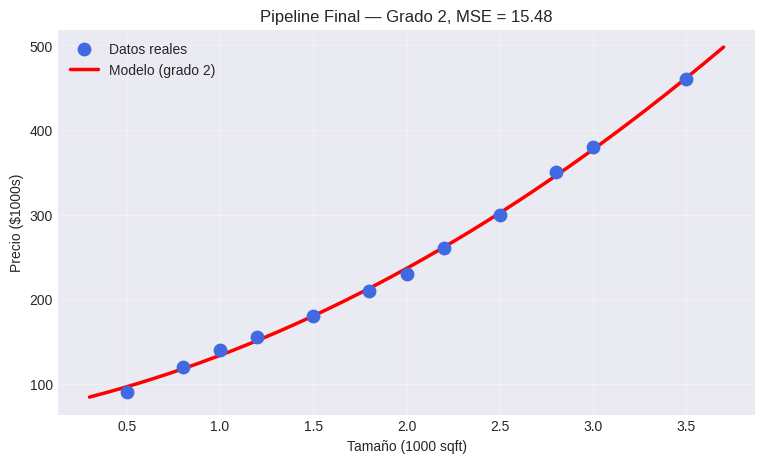

In [28]:
# Visualización del resultado final (ejecuta después de completar el pipeline)
if mse_final is not None:
    plt.figure(figsize=(9, 5))
    plt.scatter(x_train, y_train, color='royalblue', s=80, zorder=5, label='Datos reales')

    # Curva de predicción
    x_plot = np.linspace(0.3, 3.7, 200)
    X_plot_poly = create_polynomial_features(x_plot, best_degree)
    X_plot_norm = (X_plot_poly - mu) / sigma
    y_plot = X_plot_norm @ w_fin + b_fin

    plt.plot(x_plot, y_plot, 'r-', linewidth=2.5, label=f'Modelo (grado {best_degree})')
    plt.xlabel('Tamaño (1000 sqft)')
    plt.ylabel('Precio ($1000s)')
    plt.title(f'Pipeline Final — Grado {best_degree}, MSE = {mse_final:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("⚠️ Completa el pipeline arriba primero.")

---
# 6. Bonus: Verificar con sklearn

Compara tu implementación manual con la de scikit-learn. Los resultados deben ser similares.

MSE sklearn:    15.4762
MSE tu código:  15.4762

✓ Resultados similares!


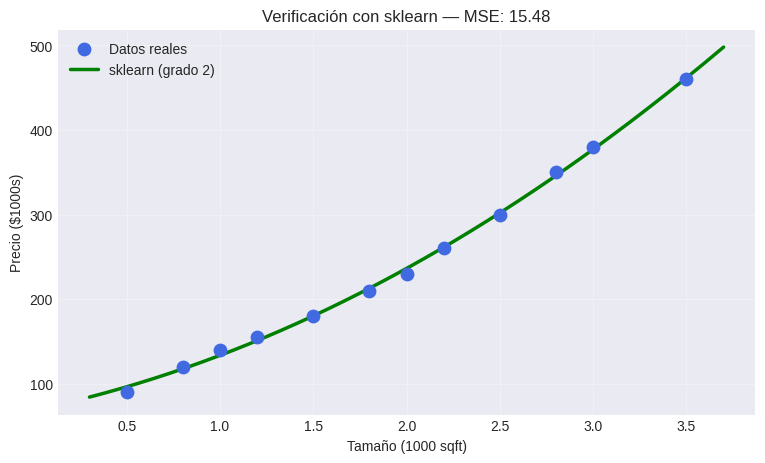


Nota: sklearn usa la solución analítica (Normal Equation), no gradient descent.
Por eso converge al óptimo exacto. Tu GD se acerca con suficientes iteraciones.


In [29]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Pipeline de sklearn equivalente a tu implementación manual
degree_to_test = 2  # usa el mismo grado que encontraste óptimo

pipe = Pipeline([
    ('poly', PolynomialFeatures(degree_to_test, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

# Entrenar
pipe.fit(x_train.reshape(-1, 1), y_train)

# Predecir
y_pred_sklearn = pipe.predict(x_train.reshape(-1, 1))
mse_sklearn = np.mean((y_pred_sklearn - y_train)**2)

print(f"MSE sklearn:    {mse_sklearn:.4f}")
if mse_final is not None:
    print(f"MSE tu código:  {mse_final:.4f}")
    print(f"\n{'✓ Resultados similares!' if abs(mse_sklearn - mse_final) < 50 else '⚠️ Hay diferencia significativa — revisa tu implementación'}")
else:
    print("(Completa la sección 5 para comparar)")

# Visualizar
plt.figure(figsize=(9, 5))
plt.scatter(x_train, y_train, color='royalblue', s=80, zorder=5, label='Datos reales')

x_plot = np.linspace(0.3, 3.7, 200)
y_plot_sk = pipe.predict(x_plot.reshape(-1, 1))
plt.plot(x_plot, y_plot_sk, 'g-', linewidth=2.5, label=f'sklearn (grado {degree_to_test})')

plt.xlabel('Tamaño (1000 sqft)')
plt.ylabel('Precio ($1000s)')
plt.title(f'Verificación con sklearn — MSE: {mse_sklearn:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nNota: sklearn usa la solución analítica (Normal Equation), no gradient descent.")
print("Por eso converge al óptimo exacto. Tu GD se acerca con suficientes iteraciones.")

---
# 7. Conclusión

## ¡Felicitaciones!

En esta práctica aprendiste a:

- **Vectorizar** operaciones usando el producto punto y multiplicación de matrices (`X @ w + b`) en lugar de loops
- Crear **features polinomiales** para capturar relaciones no-lineales, y evaluar qué grado es óptimo
- Implementar **3 métodos de feature scaling** (Min-Max, Mean Normalization, Z-Score) y comparar su efecto en la convergencia
- Construir un **pipeline completo**: features → scaling → entrenamiento → evaluación

### Conceptos Clave:
1. La multiplicación matriz × vector es una colección de productos punto (una predicción por fila)
2. Feature scaling es **esencial** cuando las features tienen escalas diferentes
3. Más features (mayor grado) no siempre es mejor → riesgo de **overfitting**
4. El pipeline correcto es: crear features → escalar → entrenar